# Forward Diffusion Visualization (Shared Pipeline)

This notebook visualizes the **forward diffusion** process (adding noise) on puzzle pose vectors and exports a GIF.

It reuses the same shared data path as training/evaluation:
- `CelebA_DataSet`
- `Puzzle_Dataset_ROT`
- `GNN_Diffusion.q_sample`

In [32]:
from pathlib import Path
import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import transforms as mpl_transforms
import imageio.v2 as imageio
import torch
import torch_geometric

if (Path.cwd() / "src").exists():
    PROJECT_ROOT = Path.cwd()
elif (Path.cwd().parent / "src").exists():
    PROJECT_ROOT = Path.cwd().parent
else:
    raise RuntimeError("Could not locate project root with a src/ directory.")

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from dataset_celeb import CelebA_DataSet
from puzzle_dataset import Puzzle_Dataset_ROT
from gnn_diffusion import GNN_Diffusion

In [33]:
cfg = {
    "dataset_path": str(PROJECT_ROOT / "data" / "CelebA-HQ"),
    "split": "train",
    "puzzle_size": 6,
    "degree": -1,
    "missing_percentage": 0,
    "batch_size": 1,
    "random_sample": True,
    # Set to an integer to force a specific sample in the selected split. Use None for random.
    "target_sample_id": 11359,
    "random_seed": None,

    # Forward diffusion schedule
    "steps": 300,
    "num_frames": 60,

    # Visualization
    "show_vector_panel": True,
    "show_vector_arrows": True,
    "arrow_length": 0.22,
    # Slightly above 0.5 hides seams between tiles; lower values reveal more gaps.
    "patch_overlap_scale": 0.502,
    # bilinear|bicubic|nearest
    "patch_interpolation": "bicubic",

    # Saving
    "make_gif": True,
    "gif_fps": 12,
    "output_dir": str(PROJECT_ROOT / "outputs" / "forward_diffusion_steps"),
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if cfg["random_seed"] is not None:
    random.seed(cfg["random_seed"])
    np.random.seed(cfg["random_seed"])
    torch.manual_seed(cfg["random_seed"])
    print(f"Random seed fixed to {cfg['random_seed']}")

Using device: cuda


In [34]:
def build_dataloader(dataset_path: str, split: str, puzzle_size: int, batch_size: int, degree: int, missing_percentage: int, random_sample: bool, target_sample_id: int | None = None):
    split_name = split.lower()
    is_train = split_name == "train"
    base_dataset = CelebA_DataSet(dataset_path, train=is_train)
    puzzle_dataset = Puzzle_Dataset_ROT(
        dataset=base_dataset,
        patch_per_dim=[(puzzle_size, puzzle_size)],
        augment=False,
        degree=degree,
        unique_graph=None,
        all_equivariant=False,
        random_dropout=False,
        missing_percentage=missing_percentage,
    )

    dataset_for_loader = puzzle_dataset
    shuffle = random_sample
    target_image_name = None

    if target_sample_id is not None:
        max_idx = len(base_dataset) - 1
        if target_sample_id < 0 or target_sample_id > max_idx:
            raise IndexError(
                f"target_sample_id={target_sample_id} is out of range for split '{split_name}'. "
                f"Valid range is [0, {max_idx}] ({len(base_dataset)} samples)."
            )
        dataset_for_loader = torch.utils.data.Subset(puzzle_dataset, [target_sample_id])
        shuffle = False
        target_image_name = base_dataset.image_names[target_sample_id]

    loader = torch_geometric.loader.DataLoader(dataset_for_loader, batch_size=batch_size, shuffle=shuffle)
    return puzzle_dataset, loader, target_image_name


def infer_patch_half_size(reference_pose: torch.Tensor, overlap_scale: float = 0.502) -> tuple[float, float]:
    xy = reference_pose[:, :2].detach().cpu()
    xs = torch.sort(torch.unique(xy[:, 0]))[0]
    ys = torch.sort(torch.unique(xy[:, 1]))[0]
    dx = float((xs[1] - xs[0]).item()) if len(xs) > 1 else 0.3
    dy = float((ys[1] - ys[0]).item()) if len(ys) > 1 else 0.3
    overlap_scale = float(np.clip(overlap_scale, 0.45, 0.55))
    return overlap_scale * dx, overlap_scale * dy


def normalize_vectors_to_fixed_length(vectors: torch.Tensor, target_length: float = 0.22, eps: float = 1e-8) -> torch.Tensor:
    norms = torch.linalg.norm(vectors, dim=1, keepdim=True)
    safe_dirs = vectors / torch.clamp(norms, min=eps)
    return torch.where(norms > eps, safe_dirs * target_length, torch.zeros_like(vectors))


def render_pose(
    ax,
    patches: torch.Tensor,
    pose: torch.Tensor,
    title: str,
    half_w: float,
    half_h: float,
    interpolation: str = "bicubic",
):
    pose = pose.detach().cpu()
    patches = patches.detach().cpu().clamp(0, 1)

    xy = pose[:, :2]
    rot = pose[:, 2:4]
    theta = torch.atan2(rot[:, 1], rot[:, 0]).numpy()

    valid = torch.isfinite(xy).all(dim=1) & torch.isfinite(rot).all(dim=1)
    xy = xy[valid]
    theta = theta[valid.numpy()]
    patches = patches[valid]

    for i in range(patches.shape[0]):
        img = patches[i].permute(1, 2, 0).numpy()
        x = float(xy[i, 0])
        y = float(xy[i, 1])
        im = ax.imshow(
            img,
            extent=[x - half_w, x + half_w, y - half_h, y + half_h],
            interpolation=interpolation,
            origin="lower",
        )
        im.set_transform(mpl_transforms.Affine2D().rotate_around(x, y, float(theta[i])) + ax.transData)

    ax.set_facecolor("black")
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(1.2, -1.2)
    ax.set_aspect("equal")
    ax.set_title(title, color="white")
    ax.axis("off")


def render_vector_field(ax, pose: torch.Tensor, title: str, show_arrows: bool, arrow_length: float):
    pose = pose.detach().cpu()
    xy = pose[:, :2]
    vec = pose[:, 2:4]

    valid = torch.isfinite(xy).all(dim=1) & torch.isfinite(vec).all(dim=1)
    xy = xy[valid]
    vec = vec[valid]

    if xy.shape[0] > 0:
        colors = plt.cm.hsv(np.linspace(0.0, 1.0, int(xy.shape[0]), endpoint=False))
        display_vec = normalize_vectors_to_fixed_length(vec, target_length=arrow_length)

        if show_arrows:
            ax.quiver(
                xy[:, 0].numpy(),
                xy[:, 1].numpy(),
                display_vec[:, 0].numpy(),
                display_vec[:, 1].numpy(),
                color=colors,
                angles="xy",
                scale_units="xy",
                scale=1.0,
                width=0.006,
                alpha=0.95,
            )

        ax.scatter(xy[:, 0].numpy(), xy[:, 1].numpy(), c=colors, s=12, alpha=0.8, linewidths=0)

    ax.set_facecolor("black")
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(1.2, -1.2)
    ax.set_aspect("equal")
    ax.set_title(title, color="white")
    ax.axis("off")


def make_frame(patches: torch.Tensor, clean_pose: torch.Tensor, noisy_pose: torch.Tensor, t_scalar: int, cfg: dict):
    # Use patch size from the clean reference only; using noisy pose makes tile size unstable.
    half_w, half_h = infer_patch_half_size(
        clean_pose, overlap_scale=float(cfg.get("patch_overlap_scale", 0.502))
    )
    interpolation = str(cfg.get("patch_interpolation", "bicubic"))

    if cfg.get("show_vector_panel", True):
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.patch.set_facecolor("black")
        render_pose(axes[0], patches, clean_pose, "Clean Puzzle (t=0)", half_w, half_h, interpolation=interpolation)
        render_pose(
            axes[1],
            patches,
            noisy_pose,
            f"Forward Diffusion (t={t_scalar})",
            half_w,
            half_h,
            interpolation=interpolation,
        )
        render_vector_field(
            axes[2],
            noisy_pose,
            f"Pose Vectors (t={t_scalar})",
            show_arrows=cfg.get("show_vector_arrows", True),
            arrow_length=float(cfg.get("arrow_length", 0.22)),
        )
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        fig.patch.set_facecolor("black")
        render_pose(axes[0], patches, clean_pose, "Clean Puzzle (t=0)", half_w, half_h, interpolation=interpolation)
        render_pose(
            axes[1],
            patches,
            noisy_pose,
            f"Forward Diffusion (t={t_scalar})",
            half_w,
            half_h,
            interpolation=interpolation,
        )

    fig.tight_layout()
    return fig


def pad_image_to_shape(image: np.ndarray, target_height: int, target_width: int) -> np.ndarray:
    if image.shape[0] == target_height and image.shape[1] == target_width:
        return image

    pad_height = target_height - image.shape[0]
    pad_width = target_width - image.shape[1]

    top = pad_height // 2
    bottom = pad_height - top
    left = pad_width // 2
    right = pad_width - left

    pad_value = 0 if image.dtype == np.uint8 else 0.0
    return np.pad(image, ((top, bottom), (left, right), (0, 0)), mode="constant", constant_values=pad_value)


def maybe_make_gif(sample_dir: Path, fps: int):
    frame_paths = sorted(sample_dir.glob("frame_*.png"))
    if not frame_paths:
        return None

    images = [imageio.imread(p) for p in frame_paths]
    max_height = max(img.shape[0] for img in images)
    max_width = max(img.shape[1] for img in images)
    images = [pad_image_to_shape(img, max_height, max_width) for img in images]

    gif_path = sample_dir / "forward_animation.gif"
    imageio.mimsave(gif_path, images, duration=1.0 / max(fps, 1))
    return gif_path

In [ ]:
i# GIF export mode: keep only the left panel (sample image) by default.
cfg.setdefault("gif_only_left_panel", True)

def make_frame(patches: torch.Tensor, clean_pose: torch.Tensor, noisy_pose: torch.Tensor, t_scalar: int, cfg: dict):
    # Use patch size from the clean reference only; using noisy pose makes tile size unstable.
    half_w, half_h = infer_patch_half_size(
        clean_pose, overlap_scale=float(cfg.get("patch_overlap_scale", 0.502))
    )
    interpolation = str(cfg.get("patch_interpolation", "bicubic"))

    if cfg.get("gif_only_left_panel", True):
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        fig.patch.set_facecolor("black")
        render_pose(
            ax,
            patches,
            clean_pose,
            "Sample Image",
            half_w,
            half_h,
            interpolation=interpolation,
        )
        fig.tight_layout()
        return fig

    if cfg.get("show_vector_panel", True):
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        fig.patch.set_facecolor("black")
        render_pose(axes[0], patches, clean_pose, "Clean Puzzle (t=0)", half_w, half_h, interpolation=interpolation)
        render_pose(
            axes[1],
            patches,
            noisy_pose,
            f"Forward Diffusion (t={t_scalar})",
            half_w,
            half_h,
            interpolation=interpolation,
        )
        render_vector_field(
            axes[2],
            noisy_pose,
            f"Pose Vectors (t={t_scalar})",
            show_arrows=cfg.get("show_vector_arrows", True),
            arrow_length=float(cfg.get("arrow_length", 0.22)),
        )
    else:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        fig.patch.set_facecolor("black")
        render_pose(axes[0], patches, clean_pose, "Clean Puzzle (t=0)", half_w, half_h, interpolation=interpolation)
        render_pose(
            axes[1],
            patches,
            noisy_pose,
            f"Forward Diffusion (t={t_scalar})",
            half_w,
            half_h,
            interpolation=interpolation,
        )

    fig.tight_layout()
    return fig

In [35]:
dataset, dataloader, target_image_name = build_dataloader(
    dataset_path=cfg["dataset_path"],
    split=cfg["split"],
    puzzle_size=cfg["puzzle_size"],
    batch_size=cfg["batch_size"],
    degree=cfg["degree"],
    missing_percentage=cfg["missing_percentage"],
    random_sample=cfg["random_sample"],
    target_sample_id=cfg.get("target_sample_id"),
)

diffusion = GNN_Diffusion(steps=int(cfg["steps"]))
diffusion.device = device
diffusion.betas = diffusion.betas.to(device)
diffusion.alphas = diffusion.alphas.to(device)
diffusion.alphas_cumprod = diffusion.alphas_cumprod.to(device)
diffusion.sqrt_alphas_cumprod = diffusion.sqrt_alphas_cumprod.to(device)
diffusion.sqrt_one_minus_alphas_cumprod = diffusion.sqrt_one_minus_alphas_cumprod.to(device)

batch = next(iter(dataloader)).to(device)
sample_id = int(batch.ind_name.view(-1)[0].item())

if cfg.get("target_sample_id") is not None:
    print(f"Target sample id: {cfg['target_sample_id']}")
    print(f"Target image file: {target_image_name}")

print(f"Loaded sample id: {sample_id}")
print(f"Dataset size: {len(dataset)}")

Target sample id: 11359
Target image file: 26017.jpg
Loaded sample id: 11359
Dataset size: 24000


In [36]:
node_mask = (batch.batch == 0)
clean_pose = batch.x[node_mask].detach()
patches = batch.patches[node_mask].detach().cpu()

# Fix one noise sample for a smooth, monotonic noising trajectory.
fixed_noise = torch.randn_like(clean_pose)

num_frames = max(2, int(cfg.get("num_frames", 60)))
t_values = torch.linspace(0, diffusion.steps - 1, steps=num_frames).round().to(torch.long)

frames_payload = []
for frame_idx, t_scalar in enumerate(t_values.tolist()):
    t_nodes = torch.full((clean_pose.shape[0],), int(t_scalar), device=device, dtype=torch.long)
    noisy_pose = diffusion.q_sample(clean_pose, t_nodes, noise=fixed_noise).detach().cpu()
    frames_payload.append((frame_idx, int(t_scalar), noisy_pose))

print(f"Prepared {len(frames_payload)} forward-diffusion frames from t=0 to t={frames_payload[-1][1]}")

Prepared 60 forward-diffusion frames from t=0 to t=299


In [37]:
output_root = Path(cfg["output_dir"])
sample_dir = output_root / f"sample_{sample_id:05d}_forward_steps_{diffusion.steps}"
sample_dir.mkdir(parents=True, exist_ok=True)

for frame_idx, t_scalar, noisy_pose in frames_payload:
    fig = make_frame(
        patches=patches,
        clean_pose=clean_pose.detach().cpu(),
        noisy_pose=noisy_pose,
        t_scalar=t_scalar,
        cfg=cfg,
    )
    frame_path = sample_dir / f"frame_{frame_idx:04d}_t_{t_scalar:03d}.png"
    fig.savefig(frame_path, dpi=130, bbox_inches="tight", facecolor="black", edgecolor="black")
    plt.close(fig)

gif_path = None
if cfg.get("make_gif", True):
    gif_path = maybe_make_gif(sample_dir, int(cfg.get("gif_fps", 12)))

print(f"Saved frames to: {sample_dir}")
if gif_path is not None:
    print(f"Saved GIF: {gif_path}")

Saved frames to: /home/tyrss/projects/deep-learning-puzzle-project/outputs/forward_diffusion_steps/sample_11359_forward_steps_300
Saved GIF: /home/tyrss/projects/deep-learning-puzzle-project/outputs/forward_diffusion_steps/sample_11359_forward_steps_300/forward_animation.gif


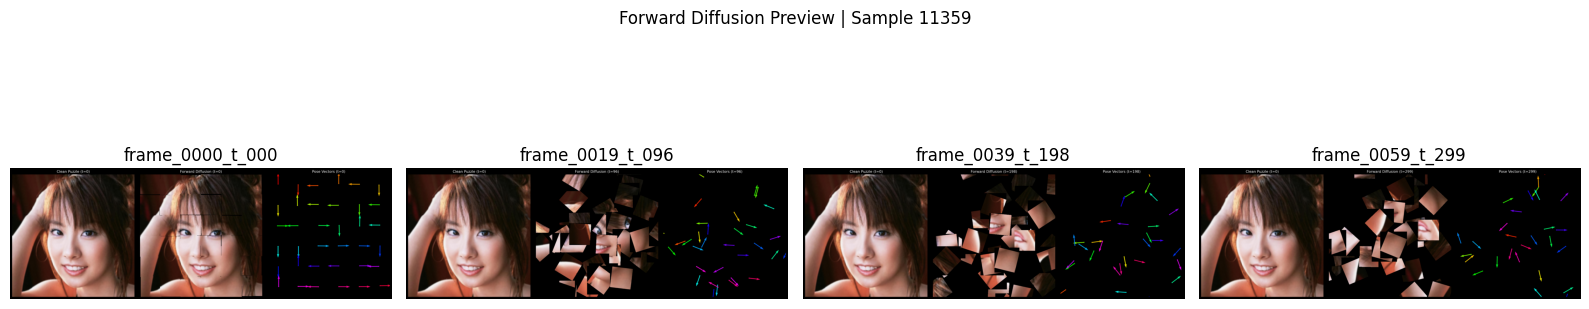

In [38]:
preview_paths = sorted(sample_dir.glob("frame_*.png"))
num_preview = min(4, len(preview_paths))

if num_preview == 0:
    print("No frames found. Run previous cell first.")
else:
    preview_idx = np.linspace(0, len(preview_paths) - 1, num_preview, dtype=int)
    selected = [preview_paths[i] for i in preview_idx]

    fig, axes = plt.subplots(1, num_preview, figsize=(4 * num_preview, 4))
    if num_preview == 1:
        axes = [axes]

    for ax, fp in zip(axes, selected):
        ax.imshow(imageio.imread(fp))
        ax.set_title(fp.stem)
        ax.axis("off")

    fig.suptitle(f"Forward Diffusion Preview | Sample {sample_id}", y=1.02)
    fig.tight_layout()
    plt.show()